In [1]:
import cv2
import os

video_path = "video2.mov"
output_dir = "frames2"
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))

frame_interval = fps  # 1 frame per second
count = 0
saved = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if count % frame_interval == 0:
        cv2.imwrite(f"{output_dir}/frame_{saved}.jpg", frame)
        saved += 1

    count += 1

cap.release()


In [2]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")  # small model for POC

frames_dir = "frames2"
detections = []

for img_name in os.listdir(frames_dir):
    img_path = os.path.join(frames_dir, img_name)
    results = model(img_path)

    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()
        for box in boxes:
            detections.append((img_path, box))



image 1/1 /Users/parinshah/Documents/NEU/Sem IV/DL/Project/frames2/frame_6.jpg: 416x640 1 person, 1 bottle, 69.7ms
Speed: 5.2ms preprocess, 69.7ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /Users/parinshah/Documents/NEU/Sem IV/DL/Project/frames2/frame_12.jpg: 416x640 2 persons, 1 tie, 1 chair, 59.2ms
Speed: 2.4ms preprocess, 59.2ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /Users/parinshah/Documents/NEU/Sem IV/DL/Project/frames2/frame_13.jpg: 416x640 3 persons, 1 wine glass, 1 cup, 1 potted plant, 47.9ms
Speed: 2.9ms preprocess, 47.9ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /Users/parinshah/Documents/NEU/Sem IV/DL/Project/frames2/frame_7.jpg: 416x640 2 persons, 1 tie, 1 bottle, 1 wine glass, 1 cup, 1 potted plant, 62.2ms
Speed: 2.2ms preprocess, 62.2ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /Users/parinshah/Documents/NEU/Sem IV/DL/Project/frames

In [3]:
from PIL import Image

crops_dir = "crops2"
os.makedirs(crops_dir, exist_ok=True)

crop_count = 0

for img_path, box in detections:
    x1, y1, x2, y2 = map(int, box)
    img = Image.open(img_path)

    crop = img.crop((x1, y1, x2, y2))
    crop.save(f"{crops_dir}/crop_{crop_count}.jpg")
    crop_count += 1


In [4]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        # Run only vision encoder
        vision_outputs = model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        pooled_output = vision_outputs.pooler_output

        # Apply projection layer (this gives final CLIP embedding)
        image_features = model.visual_projection(pooled_output)

    return image_features.cpu().numpy()


# Catalog embeddings
catalog_embeddings = []
catalog_paths = []

for img_name in os.listdir("catalog")[:100]:
    path = os.path.join("catalog", img_name)
    emb = get_embedding(path)
    catalog_embeddings.append(emb)
    catalog_paths.append(path)

catalog_embeddings = np.vstack(catalog_embeddings)


Catalog shape: (100, 512)
Query shape: (512,)

Top 3 similar products:
catalog/047225.jpg (Distance: 0.0000)
catalog/039923.jpg (Distance: 51.5094)
catalog/058311.jpg (Distance: 52.7786)


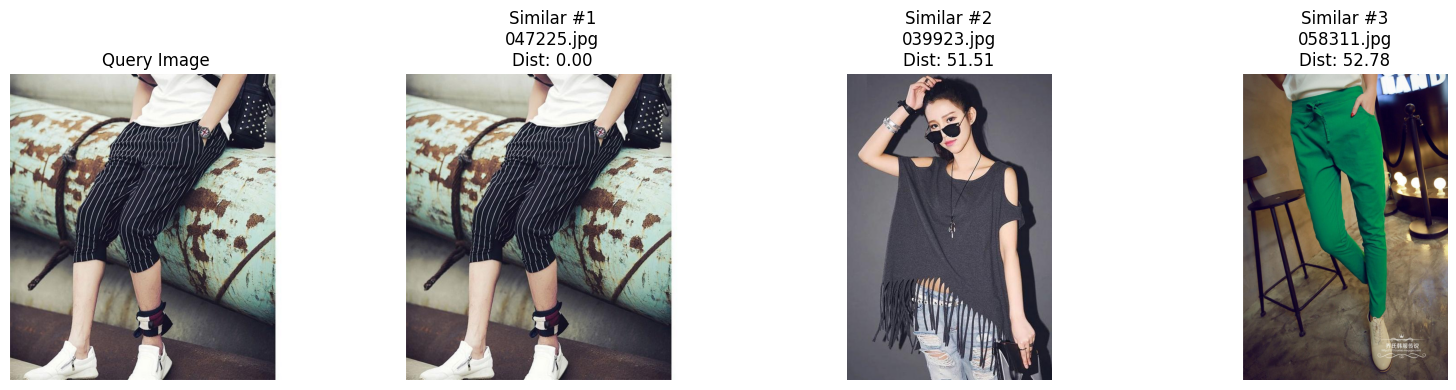

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# -----------------------------
# 1️⃣ Ensure float32 and get query embedding
# -----------------------------
catalog_embeddings = catalog_embeddings.astype(np.float32)
query_img_path = "catalog/047225.jpg"
query_embedding = get_embedding(query_img_path).astype(np.float32).reshape(-1)

print("Catalog shape:", catalog_embeddings.shape)
print("Query shape:", query_embedding.shape)

# -----------------------------
# 2️⃣ Compute L2 distance efficiently
# -----------------------------
catalog_norms = np.sum(catalog_embeddings ** 2, axis=1)   # (N,)
query_norm = np.sum(query_embedding ** 2)                 # scalar

distances = catalog_norms + query_norm - 2 * np.dot(catalog_embeddings, query_embedding)
distances = np.maximum(distances, 0)  # Numerical stability

# -----------------------------
# 3️⃣ Get top 3 similar indices
# -----------------------------
top_k = np.argsort(distances)[:3]

print("\nTop 3 similar products:")
for idx in top_k:
    print(f"{catalog_paths[idx]} (Distance: {float(distances[idx]):.4f})")

# -----------------------------
# 4️⃣ Display images side by side
# -----------------------------
plt.figure(figsize=(16, 4))

# Show query image
query_img = mpimg.imread(query_img_path)
plt.subplot(1, 4, 1)
plt.imshow(query_img)
plt.title("Query Image")
plt.axis('off')

# Show top 3 similar images
for i, idx in enumerate(top_k):
    img_path = catalog_paths[idx]
    img = mpimg.imread(img_path)
    
    plt.subplot(1, 4, i + 2)
    plt.imshow(img)
    plt.title(f"Similar #{i+1}\n{img_path.split('/')[-1]}\nDist: {distances[idx]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# # Ensure float32
# catalog_embeddings = catalog_embeddings.astype("float32")
# query_embedding = get_embedding("crops2/crop_0.jpg").astype("float32")

# # Compute L2 distances manually
# distances = np.linalg.norm(catalog_embeddings - query_embedding, axis=1)

# # Get top 3 smallest distances
# top_k = np.argsort(distances)[:3]

# for idx in top_k:
#     print("Similar product:", catalog_paths[idx])

In [ ]:
# import boto3
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from pathlib import Path

# s3 = boto3.client(
#     's3',
#     aws_access_key_id='',
#     aws_secret_access_key='',
#     region_name='us-east-1'  # optional
# )
# BUCKET = 'cs7150-parin-smit'
# LOCAL = Path('/Users/parinshah/Documents/NEU/Sem IV/DL/Project/DeepFashion2')
# PREFIX = 'train/'

# def upload(file):
#     key = PREFIX + str(file.relative_to(LOCAL))
#     s3.upload_file(str(file), BUCKET, key)
#     return key

# files = list(LOCAL.rglob('*'))
# files = [f for f in files if f.is_file()]

# with ThreadPoolExecutor(max_workers=50) as ex:
#     futures = {ex.submit(upload, f): f for f in files}
#     for i, fut in enumerate(as_completed(futures)):
#         if i % 1000 == 0:
#             print(f"{i}/{len(files)} uploaded")

0/510875 uploaded
1000/510875 uploaded
2000/510875 uploaded
3000/510875 uploaded
4000/510875 uploaded
5000/510875 uploaded
6000/510875 uploaded
7000/510875 uploaded
8000/510875 uploaded
9000/510875 uploaded
10000/510875 uploaded
11000/510875 uploaded
12000/510875 uploaded
13000/510875 uploaded
14000/510875 uploaded
15000/510875 uploaded
16000/510875 uploaded
17000/510875 uploaded
18000/510875 uploaded
19000/510875 uploaded
20000/510875 uploaded
21000/510875 uploaded
22000/510875 uploaded
23000/510875 uploaded
24000/510875 uploaded
25000/510875 uploaded
26000/510875 uploaded
27000/510875 uploaded
28000/510875 uploaded
29000/510875 uploaded
30000/510875 uploaded
31000/510875 uploaded
32000/510875 uploaded
33000/510875 uploaded
34000/510875 uploaded
35000/510875 uploaded
36000/510875 uploaded
37000/510875 uploaded
38000/510875 uploaded
39000/510875 uploaded
40000/510875 uploaded
41000/510875 uploaded
42000/510875 uploaded
43000/510875 uploaded
44000/510875 uploaded
45000/510875 uploaded
4